In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

In [3]:
# 2. LOAD DATASETS

df_customers = pd.read_parquet(
    r"clean_datasets/customer_features_clean.parquet"
)

df_clusters = pd.read_excel(
    r"clusters/cluster_individuals.xlsx"
)

In [4]:
# 3. MERGE DATASETS

df = df_customers.merge(
    df_clusters,
    on=["customer_id", "risk_rating"],
    how="left"
)

print(df.head())

print("\nShape:")
print(df.shape)

   customer_id municipality risk_rating onboarding_date  age  assets_total  \
0            1     Medellín         low      2024-03-06   20      9,644.53   
1            2      Armenia         low      2019-12-14   62     31,913.51   
2            4  Santa Marta      medium      2017-08-30   62     67,375.64   
3            5  Santa Marta         low      2019-04-02   53     27,237.00   
4            6   Valledupar         low      2023-01-21   30     37,064.28   

   liabilities_total  monthly_income  monthly_expenses  pep_flag  \
0           4,848.53        5,348.34          4,453.54         0   
1          25,856.24        3,575.39          1,502.09         0   
2          16,591.10        2,871.72          2,760.11         0   
3          13,887.45        8,846.98          6,561.25         0   
4          13,565.81        7,412.12          7,935.29         0   

   tx_count_credit  tx_count_debit  amount_sum_credit  amount_sum_debit  \
0             0.08            0.08          10,

In [5]:
# 4. CREATE SEGMENT COLUMN

risk_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "low": 1,
    "medium": 2,
    "high": 3
}

df["risk_num"] = df["risk_rating"].map(risk_map)

df["segment"] = (
    "cluster_"
    + df["risk_num"].astype(str)
    + "_"
    + df["cluster"].astype(str)
)


INDIVIDUALS PER SEGMENT
        segment  count
0   cluster_1_1    906
1   cluster_1_2    698
2   cluster_1_3    525
3   cluster_1_0    462
4   cluster_2_2    284
5   cluster_2_1    245
6   cluster_2_3    141
7   cluster_2_0    134
8   cluster_3_1     60
9   cluster_3_2     38
10  cluster_3_0     31


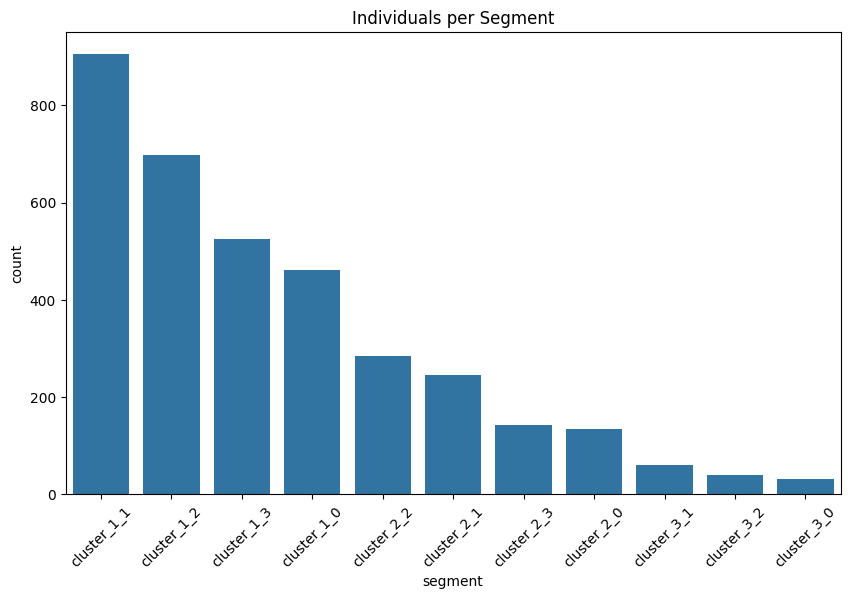

In [6]:
# 5. COUNT INDIVIDUALS PER SEGMENT

segment_counts = (
    df["segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "segment",
    "count"
]

print("\n==============================")
print("INDIVIDUALS PER SEGMENT")
print("==============================")

print(segment_counts)

# Histogram

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_counts,
    x="segment",
    y="count"
)

plt.title("Individuals per Segment")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# 6. SELECT FEATURES

features = [
    'assets_total',
    'liabilities_total',
    'monthly_income',
    'monthly_expenses',
    'tx_count_credit',
    'tx_count_debit',
    'amount_sum_credit',
    'amount_sum_debit'
]


RISK RATING: low

Shape:
(2591, 17)
Fitting 3 folds for each of 36 candidates, totalling 108 fits


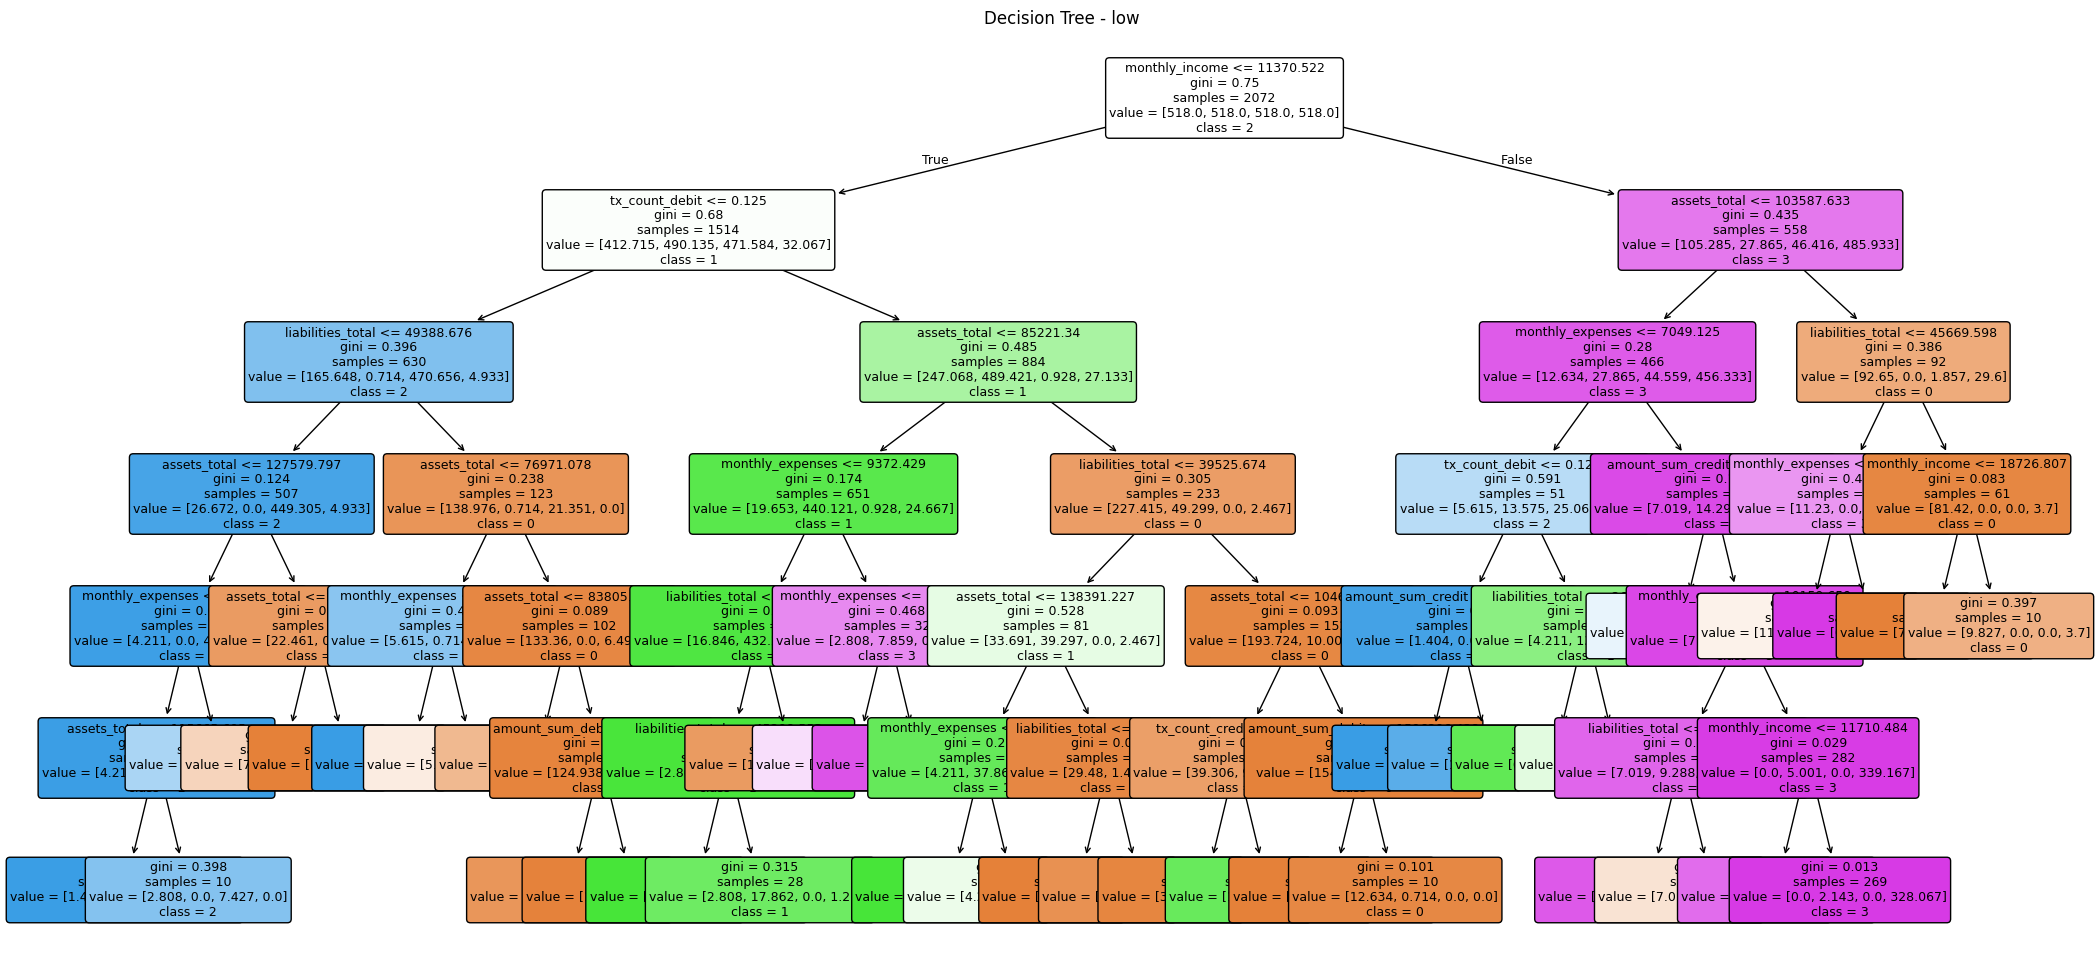


MODEL PERFORMANCE - low
Accuracy          : 0.9133
Weighted Precision: 0.9179
Weighted Recall   : 0.9133
Weighted F1-Score : 0.9144

CLASSIFICATION REPORT - low
              precision  recall  f1-score  support
0                  0.83    0.94      0.88    93.00
1                  0.96    0.91      0.93   181.00
2                  0.97    0.92      0.94   140.00
3                  0.85    0.90      0.87   105.00
accuracy           0.91    0.91      0.91     0.91
macro avg          0.90    0.92      0.91   519.00
weighted avg       0.92    0.91      0.91   519.00


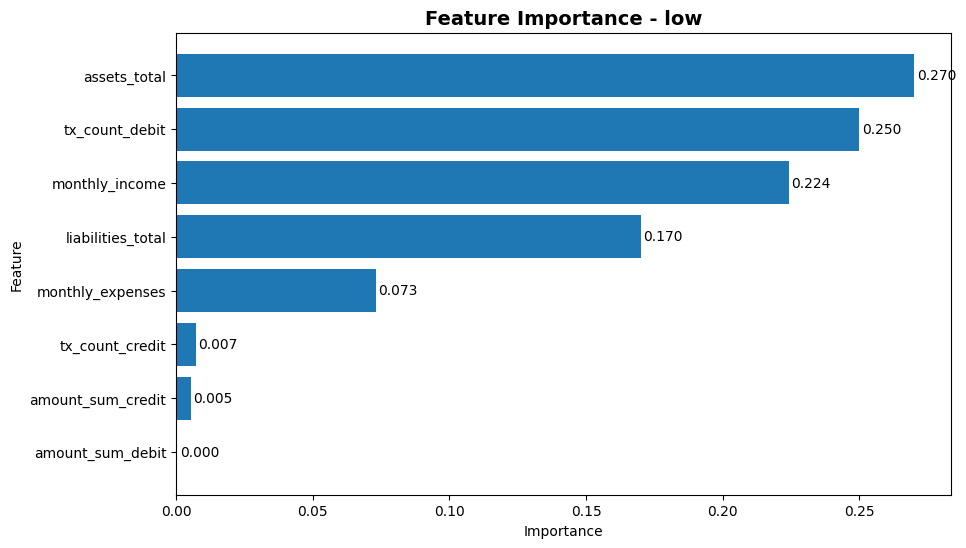


RULES - low

------------------------------------------------
Risk Rating : low
Cluster     : 0
Samples     : 1
Purity      : 1.0

RULE:
monthly_income <= 11370.52 AND 
tx_count_debit <= 0.13 AND 
liabilities_total <= 49388.68 AND 
assets_total > 127579.80 AND 
assets_total > 149991.77

------------------------------------------------
Risk Rating : low
Cluster     : 0
Samples     : 1
Purity      : 0.512

RULE:
monthly_income <= 11370.52 AND 
tx_count_debit <= 0.13 AND 
liabilities_total > 49388.68 AND 
assets_total <= 76971.08 AND 
monthly_expenses > 4844.48

------------------------------------------------
Risk Rating : low
Cluster     : 0
Samples     : 1
Purity      : 0.694

RULE:
monthly_income <= 11370.52 AND 
tx_count_debit <= 0.13 AND 
liabilities_total > 49388.68 AND 
assets_total > 76971.08 AND 
assets_total <= 83805.14

------------------------------------------------
Risk Rating : low
Cluster     : 0
Samples     : 1
Purity      : 0.858

RULE:
monthly_income <= 11370.52 AND 


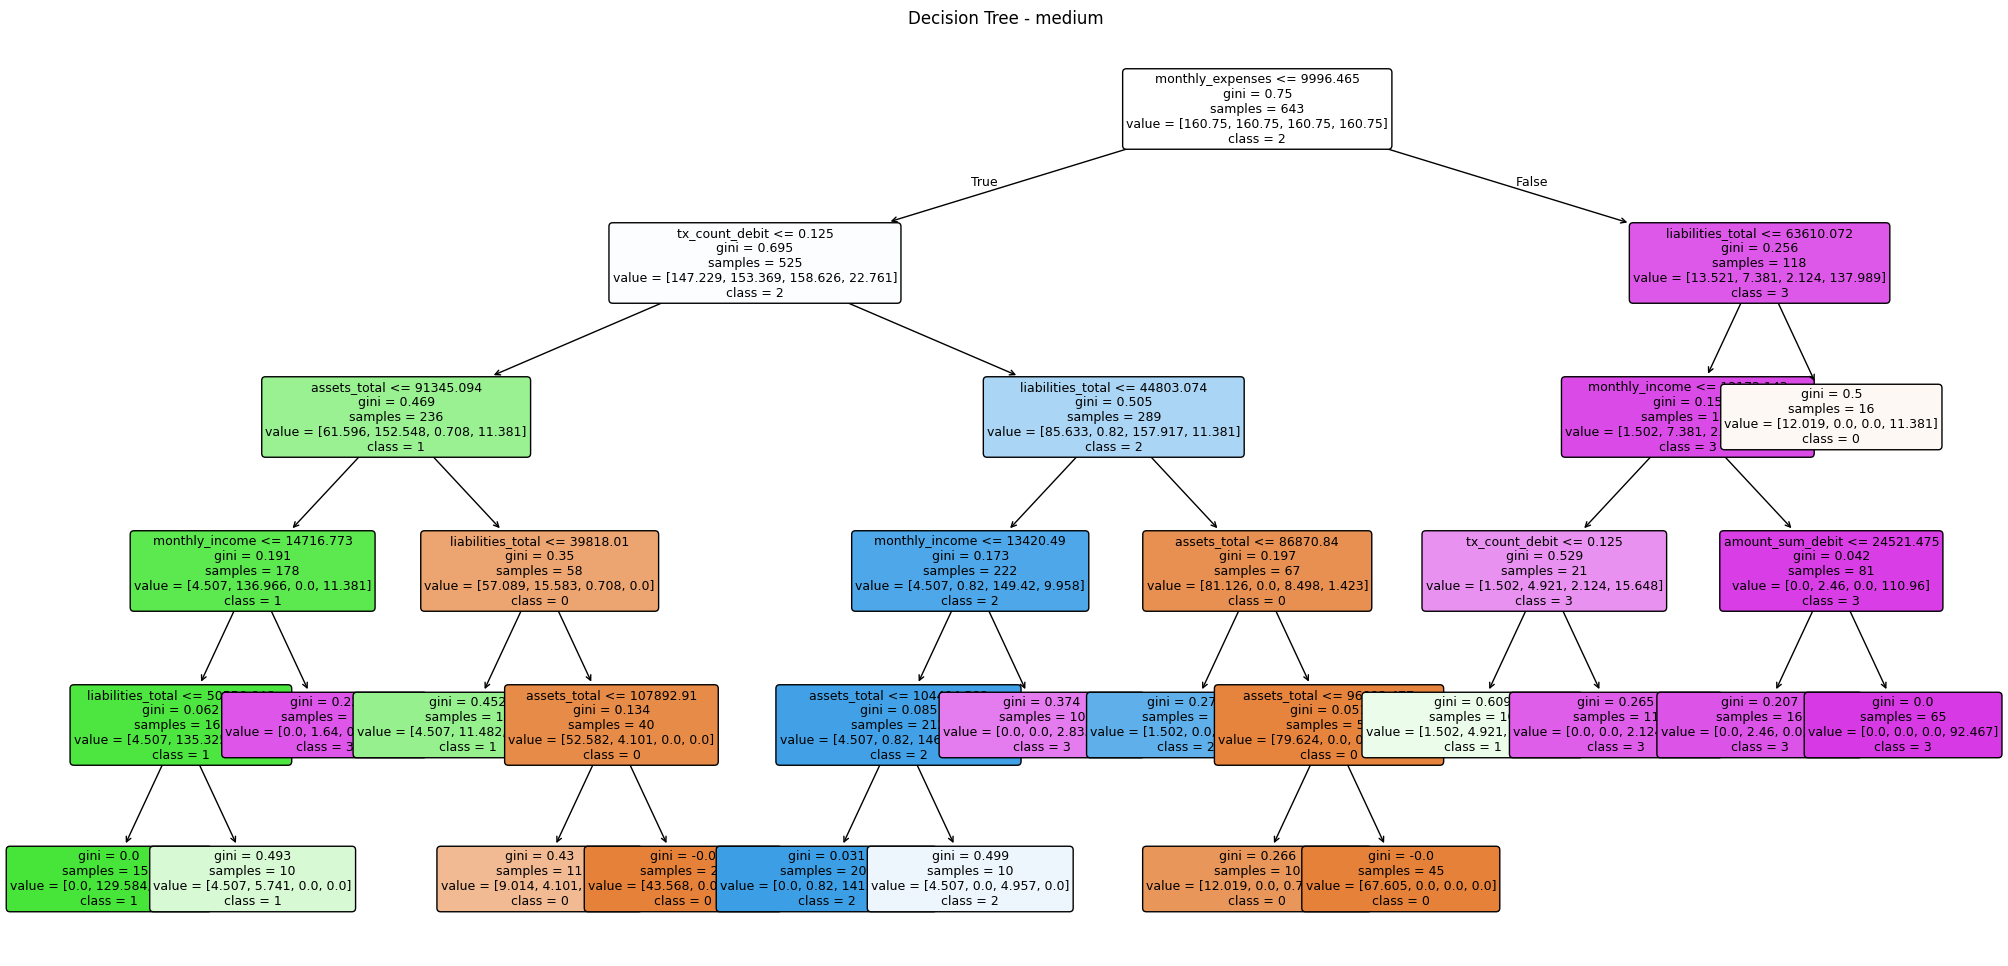


MODEL PERFORMANCE - medium
Accuracy          : 0.8882
Weighted Precision: 0.8857
Weighted Recall   : 0.8882
Weighted F1-Score : 0.8860

CLASSIFICATION REPORT - medium
              precision  recall  f1-score  support
0                  0.79    0.70      0.74    27.00
1                  0.90    0.94      0.92    49.00
2                  0.92    0.96      0.94    57.00
3                  0.89    0.82      0.85    28.00
accuracy           0.89    0.89      0.89     0.89
macro avg          0.87    0.86      0.86   161.00
weighted avg       0.89    0.89      0.89   161.00


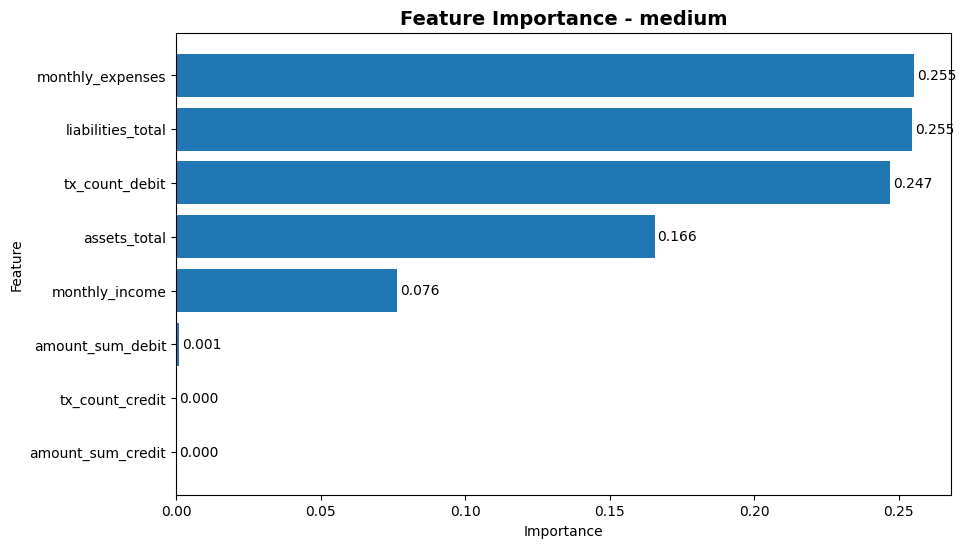


RULES - medium

------------------------------------------------
Risk Rating : medium
Cluster     : 0
Samples     : 1
Purity      : 0.687

RULE:
monthly_expenses <= 9996.46 AND 
tx_count_debit <= 0.13 AND 
assets_total > 91345.09 AND 
liabilities_total > 39818.01 AND 
assets_total <= 107892.91

------------------------------------------------
Risk Rating : medium
Cluster     : 0
Samples     : 1
Purity      : 1.0

RULE:
monthly_expenses <= 9996.46 AND 
tx_count_debit <= 0.13 AND 
assets_total > 91345.09 AND 
liabilities_total > 39818.01 AND 
assets_total > 107892.91

------------------------------------------------
Risk Rating : medium
Cluster     : 0
Samples     : 1
Purity      : 0.849

RULE:
monthly_expenses <= 9996.46 AND 
tx_count_debit > 0.13 AND 
liabilities_total > 44803.07 AND 
assets_total > 86870.84 AND 
assets_total <= 96093.48

------------------------------------------------
Risk Rating : medium
Cluster     : 0
Samples     : 1
Purity      : 1.0

RULE:
monthly_expenses <= 9

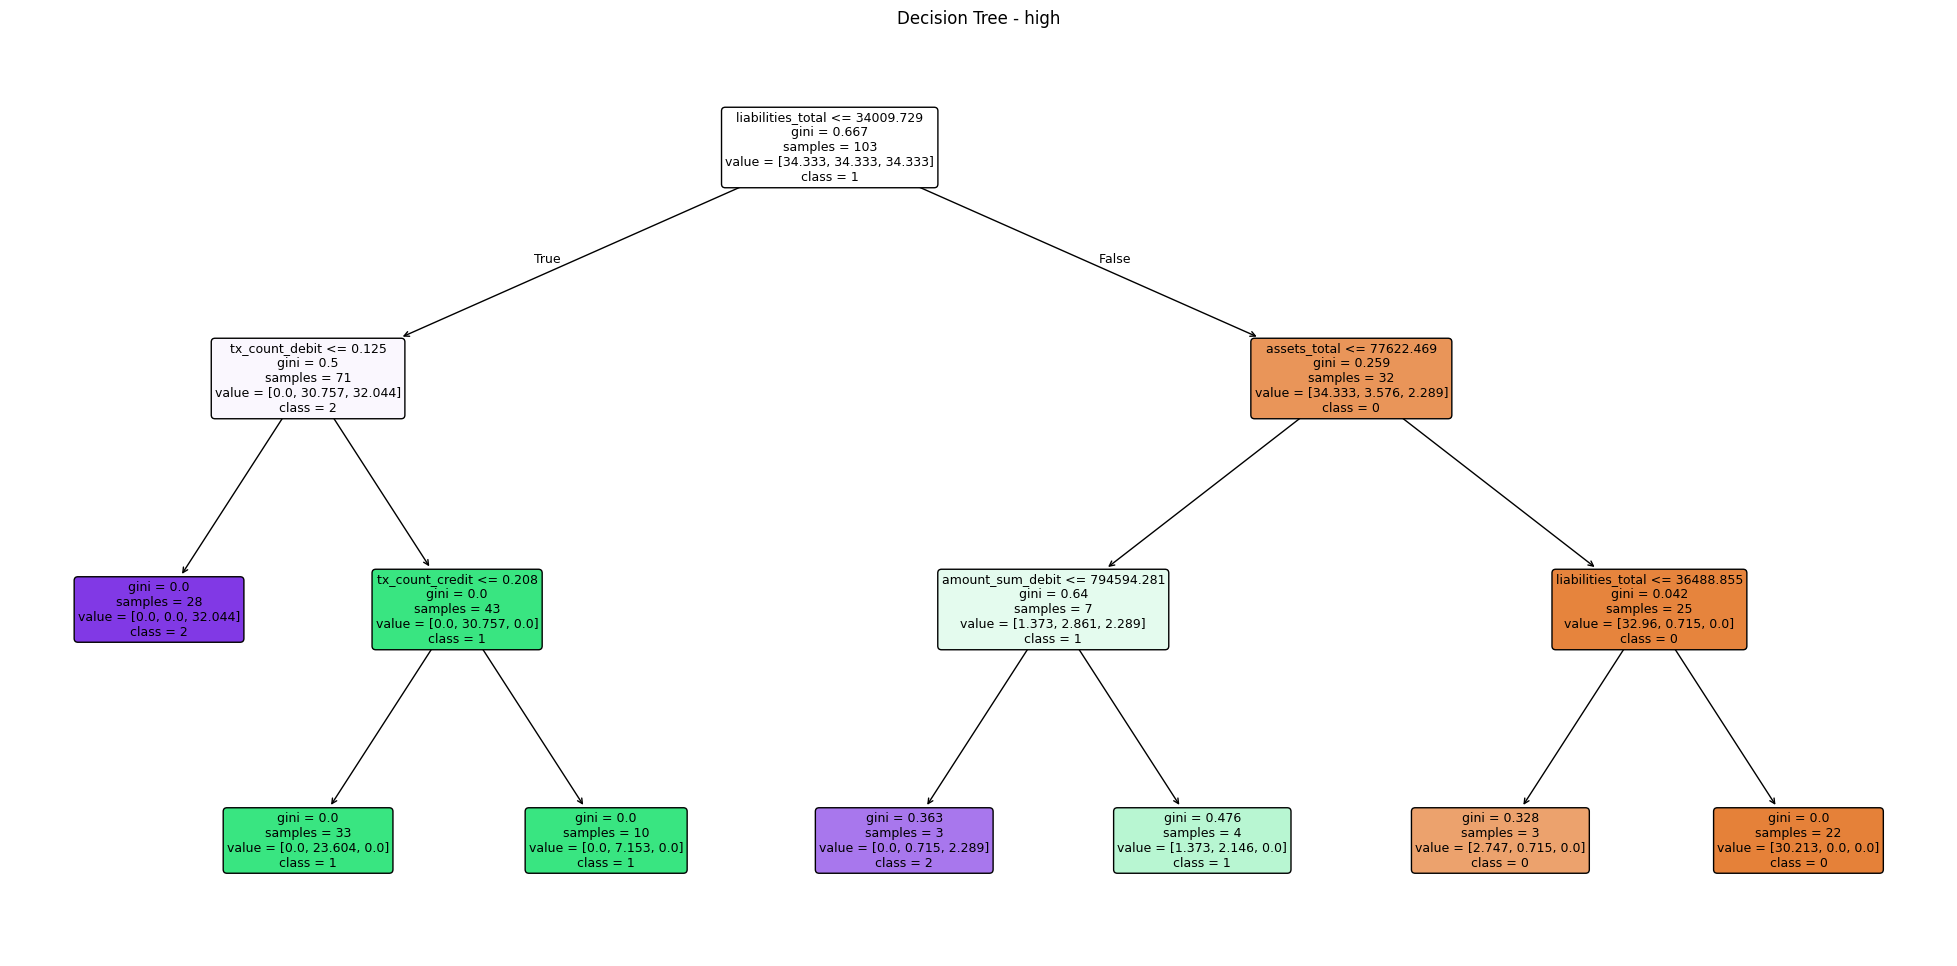


MODEL PERFORMANCE - high
Accuracy          : 0.8462
Weighted Precision: 0.8606
Weighted Recall   : 0.8462
Weighted F1-Score : 0.8442

CLASSIFICATION REPORT - high
              precision  recall  f1-score  support
0                  1.00    0.67      0.80     6.00
1                  0.85    0.92      0.88    12.00
2                  0.78    0.88      0.82     8.00
accuracy           0.85    0.85      0.85     0.85
macro avg          0.88    0.82      0.83    26.00
weighted avg       0.86    0.85      0.84    26.00


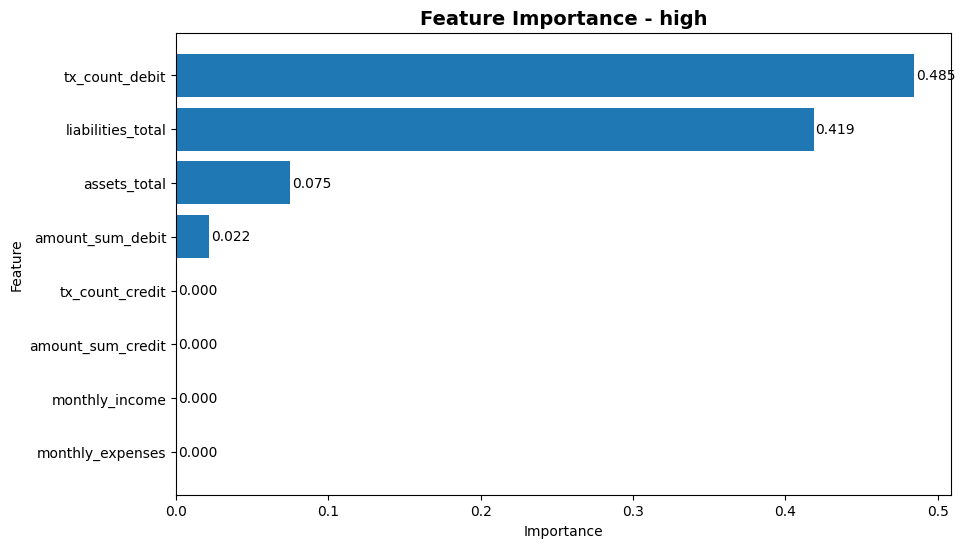


RULES - high

------------------------------------------------
Risk Rating : high
Cluster     : 0
Samples     : 1
Purity      : 1.0

RULE:
liabilities_total > 34009.73 AND 
assets_total > 77622.47 AND 
liabilities_total > 36488.86

------------------------------------------------
Risk Rating : high
Cluster     : 0
Samples     : 0
Purity      : 0.793

RULE:
liabilities_total > 34009.73 AND 
assets_total > 77622.47 AND 
liabilities_total <= 36488.86

------------------------------------------------
Risk Rating : high
Cluster     : 1
Samples     : 1
Purity      : 1.0

RULE:
liabilities_total <= 34009.73 AND 
tx_count_debit > 0.13 AND 
tx_count_credit <= 0.21

------------------------------------------------
Risk Rating : high
Cluster     : 1
Samples     : 1
Purity      : 1.0

RULE:
liabilities_total <= 34009.73 AND 
tx_count_debit > 0.13 AND 
tx_count_credit > 0.21

------------------------------------------------
Risk Rating : high
Cluster     : 1
Samples     : 1
Purity      : 0.61

RUL

In [45]:
# LOOP BY RISK RATING

risk_groups = df['risk_rating'].unique()

for risk in risk_groups:

    print('\n================================================')
    print(f'RISK RATING: {risk}')
    print('================================================')

    # =====================================================
    # FILTER DATASET
    # =====================================================

    risk_df = df[
        df['risk_rating'] == risk
    ].copy()

    print('\nShape:')
    print(risk_df.shape)

    # =====================================================
    # FEATURES AND TARGET
    # =====================================================

    X = risk_df[features]

    y = risk_df['cluster'].astype(str)

    label_encoder = LabelEncoder()

    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )

    # =====================================================
    # HYPERPARAMETERS
    # =====================================================

    # LOW RISK
    if str(risk).lower() == 'low':

        param_grid = {
            'max_depth': [4,5,6,7],
            'min_samples_split': [20,30,50],
            'min_samples_leaf': [10,20,30]
        }

    # MEDIUM RISK
    elif str(risk).lower() == 'medium':

        param_grid = {
            'max_depth': [3,4,5],
            'min_samples_split': [15,20,30],
            'min_samples_leaf': [10,15,20]
        }

    # HIGH RISK
    else:

        param_grid = {
            'max_depth': [2,3],
            'min_samples_split': [5,10],
            'min_samples_leaf': [3,5]
        }

    tree_model = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    )

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    grid_search = GridSearchCV(
        estimator=tree_model,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )


    # =====================================================
    # MODEL METRICS
    # =====================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()

    # Save metrics

    weighted_precision = report_df.loc[
        "weighted avg",
        "precision"
    ]

    weighted_recall = report_df.loc[
        "weighted avg",
        "recall"
    ]

    weighted_f1 = report_df.loc[
        "weighted avg",
        "f1-score"
    ]

    plt.figure(figsize=(25,12))

    plot_tree(
        best_model,
        feature_names=features,
        class_names=label_encoder.classes_,
        filled=True,
        rounded=True,
        fontsize=9
    )

    plt.title(f'Decision Tree - {risk}')

    plt.show()

    print("\n================================================")
    print(f"MODEL PERFORMANCE - {risk}")
    print("================================================")

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall   : {weighted_recall:.4f}")
    print(f"Weighted F1-Score : {weighted_f1:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT TABLE
    # =====================================================

    report_df = report_df.round(3)

    print("\n================================================")
    print(f"CLASSIFICATION REPORT - {risk}")
    print("================================================")

    print(report_df)

    # Optional export

    report_df.to_excel(
        f"classification_report/customer_classification_report_{risk}.xlsx"
    )
    
    # =====================================================
    # FEATURE IMPORTANCE
    # =====================================================

    importance_df = pd.DataFrame({

        "feature": features,

        "importance": best_model.feature_importances_

    })

    importance_df = importance_df.sort_values(
        by="importance",
        ascending=True
    )

    plt.figure(figsize=(10,6))

    bars = plt.barh(
        importance_df["feature"],
        importance_df["importance"]
    )

    # Add values

    for bar in bars:

        width = bar.get_width()

        plt.text(
            width + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{width:.3f}",
            va='center'
        )

    plt.title(
        f"Feature Importance - {risk}",
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

    # =====================================================
    # EXTRACT TREE RULES
    # =====================================================

    tree_rules = []

    tree_ = best_model.tree_

    feature_names_tree = [

        features[i]
        if i != -2
        else "undefined"

        for i in tree_.feature
    ]

    # =====================================================
    # RECURSIVE FUNCTION
    # =====================================================

    def extract_rules(node, conditions):

        # -------------------------------------------------
        # INTERNAL NODE
        # -------------------------------------------------

        if tree_.feature[node] != -2:

            feature = feature_names_tree[node]

            threshold = tree_.threshold[node]

            # LEFT BRANCH

            left_conditions = conditions + [
                f"{feature} <= {threshold:.2f}"
            ]

            extract_rules(
                tree_.children_left[node],
                left_conditions
            )

            # RIGHT BRANCH

            right_conditions = conditions + [
                f"{feature} > {threshold:.2f}"
            ]

            extract_rules(
                tree_.children_right[node],
                right_conditions
            )

        # -------------------------------------------------
        # LEAF NODE
        # -------------------------------------------------

        else:

            value = tree_.value[node][0]

            predicted_class = np.argmax(value)

            cluster = label_encoder.inverse_transform(
                [predicted_class]
            )[0]

            samples = int(np.sum(value))

            purity = (
                np.max(value) / np.sum(value)
            )

            rule_text = " AND \n".join(conditions)

            tree_rules.append({

                "risk_rating": risk,

                "cluster": cluster,

                "samples": samples,

                "purity": round(purity, 3),

                "rule": rule_text
            })

    # =====================================================
    # RUN EXTRACTION
    # =====================================================

    extract_rules(0, [])

    # =====================================================
    # RULES DATAFRAME
    # =====================================================

    rules_df = pd.DataFrame(tree_rules)

    # =====================================================
    # SORT RULES
    # =====================================================

    rules_df = rules_df.sort_values(

        by=[
            "cluster",
            "samples"
        ],

        ascending=[True, False]
    )

    # =====================================================
    # DISPLAY RULES
    # =====================================================

    print("\n================================================")
    print(f"RULES - {risk}")
    print("================================================")

    for idx, row in rules_df.iterrows():

        print("\n------------------------------------------------")

        print(f"Risk Rating : {row['risk_rating']}")

        print(f"Cluster     : {row['cluster']}")

        print(f"Samples     : {row['samples']}")

        print(f"Purity      : {row['purity']}")

        print("\nRULE:")

        print(row['rule'])

    # =====================================================
    # EXPORT RULES
    # =====================================================

    rules_df.to_excel(

        f"rules/customer_rules_{risk}.xlsx",

        index=False
    )

    print(f"\nRules exported: customer_rules_{risk}.xlsx")